# Quickstart: ECMWF IFS ENS 46-day forecast

Daily forecasts on a 1.5° global grid, with 101 members extending to day 46. ECMWF makes these sub-seasonal forecasts available after a 48-hour delay.

[Dataset documentation](https://dynamical.org/catalog/ecmwf-ifs-ens-forecast-46-day-daily-1-5-degree/). Data licensed under [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/) and [ECMWF Terms of Use](https://apps.ecmwf.int/datasets/licences/general/).

In [ ]:
# If running locally, follow README.md for simple dependency installation.
# If using Google Colab, run this cell.
!uv pip install dynamical-catalog cartopy

In [2]:
import dynamical_catalog

ds = dynamical_catalog.open("ecmwf-ifs-ens-forecast-46-day-daily-1-5-degree", chunks=None)
ds

<xarray.Dataset> Size: 5TB
Dimensions:                                                   (init_time: 256,
                                                               lead_time: 47,
                                                               ensemble_member: 101,
                                                               latitude: 121,
                                                               longitude: 240)
Coordinates:
  * init_time                                                 (init_time) datetime64[ns] 2kB ...
    ingested_forecast_length                                  (init_time) timedelta64[us] 2kB ...
    expected_forecast_length                                  (init_time) timedelta64[us] 2kB ...
  * lead_time                                                 (lead_time) timedelta64[us] 376B ...
    valid_time                                                (init_time, lead_time) datetime64[ns] 96kB ...
  * ensemble_member                                           (ensemble_member) int16 202B ...
  * latitude                                                  (latitude) float64 968B ...
  * longitude                                                 (longitude) float64 2kB ...
    spatial_ref                                               int64 8B ...
Data variables: (12/35)
    average_convective_available_potential_energy_atmosphere  (init_time, lead_time, ensemble_member, latitude, longitude) float32 141GB ...
    downward_short_wave_radiation_flux_surface                (init_time, lead_time, ensemble_member, latitude, longitude) float32 141GB ...
    downward_latent_heat_flux_surface                         (init_time, lead_time, ensemble_member, latitude, longitude) float32 141GB ...
    eastward_turbulent_surface_stress                         (init_time, lead_time, ensemble_member, latitude, longitude) float32 141GB ...
    downward_sensible_heat_flux_surface                       (init_time, lead_time, ensemble_member, latitude, longitude) float32 141GB ...
    average_dew_point_temperature_2m                          (init_time, lead_time, ensemble_member, latitude, longitude) float32 141GB ...
    ...                                                        ...
    snow_water_equivalent_surface                             (init_time, lead_time, ensemble_member, latitude, longitude) float32 141GB ...
    sea_surface_temperature                                   (init_time, lead_time, ensemble_member, latitude, longitude) float32 141GB ...
    total_column_water_atmosphere                             (init_time, lead_time, ensemble_member, latitude, longitude) float32 141GB ...
    wind_v_10m                                                (init_time, lead_time, ensemble_member, latitude, longitude) float32 141GB ...
    wind_u_10m                                                (init_time, lead_time, ensemble_member, latitude, longitude) float32 141GB ...
    total_cloud_cover_atmosphere                              (init_time, lead_time, ensemble_member, latitude, longitude) float32 141GB ...
Attributes:
    dataset_id:           ecmwf-ifs-ens-forecast-46-day-daily-1-5-degree
    dataset_version:      0.2.0
    name:                 ECMWF IFS ENS forecast, 46 day, daily, 1.5 degree
    description:          Sub-seasonal-range ensemble weather forecasts from ...
    attribution:          ECMWF IFS ENS sub-seasonal-range forecast data proc...
    license:              CC-BY-4.0
    spatial_domain:       Global
    spatial_resolution:   1.5 degrees (~165km)
    time_domain:          Forecasts initialized 2026-01-01 00:00:00 UTC to Pr...
    time_resolution:      Forecasts initialized every 24 hours
    forecast_domain:      Forecast lead time 0-1104 hours (0-46 days) ahead
    forecast_resolution:  Forecast step 24 hourly

Daily means and rates start at lead time 24 hours; the 0-hour step has no preceding day to summarize.

## How wide was the temperature outlook for Bordeaux?

France experienced a [heatwave on 17–30 June 2026](https://meteofrance.com/presse/bilan-climatique-de-juin-2026-le-mois-de-juin-le-plus-chaud-jamais-enregistre-avec-une). The 1 June ensemble below gives daily mean temperatures at the nearest grid cell to Bordeaux.

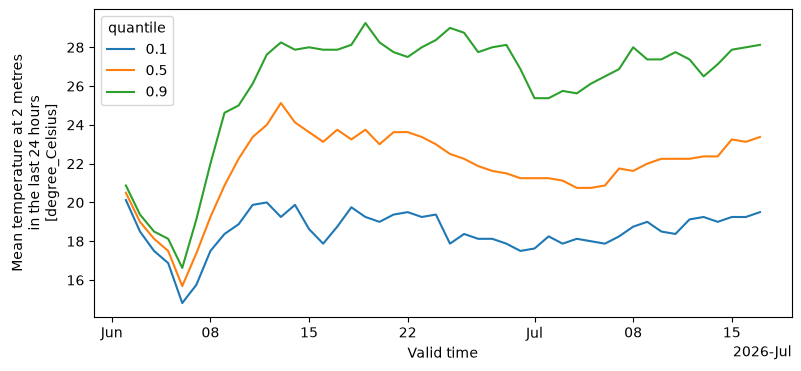

In [3]:
temperature = (
    ds["average_temperature_2m"]
    .sel(init_time="2026-06-01T00", latitude=44.84, longitude=-0.58, method="nearest")
    .sel(lead_time=slice("1d", "46d"))
    .load()
)
temperature.quantile([0.1, 0.5, 0.9], dim="ensemble_member", keep_attrs=True).plot(
    x="valid_time", hue="quantile", figsize=(9, 4)
);

## Was there a wet signal four weeks before the New York floods?

[Heavy rain affected eastern New York and western New England on 28–30 July 2026](https://www.weather.gov/aly/july2026flashflood). The 1 July ensemble-mean weekly forecast shows no distinct rainfall focus over the flooded region at that lead.

In [4]:
rain = (
    ds["precipitation_surface"]
    .sel(
        init_time="2026-07-01T00", lead_time=slice("1d", "46d"),
        latitude=slice(50, 30), longitude=slice(-90, -60),
    )
    .load()
)
# Each daily mean rate is in kg m-2 s-1, equivalent to mm/s.
weekly = (rain.mean("ensemble_member") * 86400).rolling(lead_time=7).sum()
weekly = weekly.isel(lead_time=slice(6, None))
weekly.attrs = {"long_name": "Ensemble-mean 7-day precipitation", "units": "mm"}

In [5]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import HTML
from matplotlib.animation import FuncAnimation

fig, ax = plt.subplots(figsize=(8, 5), subplot_kw={"projection": ccrs.PlateCarree()})
mesh = weekly.isel(lead_time=0).plot(
    ax=ax, transform=ccrs.PlateCarree(), cmap="Blues", vmin=0, vmax=float(weekly.max())
)
ax.coastlines()
ax.add_feature(cfeature.STATES, linewidth=0.4)

def update(i):
    mesh.set_array(weekly.isel(lead_time=i).values.ravel())
    end = pd.Timestamp(weekly.valid_time.values[i])
    start = end - pd.Timedelta(days=7)
    ax.set_title(f"{start:%d %b}–{end:%d %b %Y} UTC | initialized 1 July 2026")

anim = FuncAnimation(fig, update, frames=weekly.sizes["lead_time"], interval=250)
plt.close(fig)
HTML(anim.to_jshtml())

### Community challenge

How stable is the wet-week outlook across successive initializations? Does a wider temperature ensemble correspond to larger errors when compared with observations?